In [1]:
import sys
sys.path.insert(0, '../src')
    
import pandas as pd; pd.set_option('display.max_columns', 100)
import numpy as np
import matplotlib.pyplot as plt; plt.style.use('ggplot')
import seaborn as sns
import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.neural_network import MLPClassifier

from model import FFNN
from layers.dense import Dense
from initializers import initialize_uniform

sns.set()

In [2]:
SETTING = {
    'random_state': 42,
    'test_size': 0.2,
    'TARGET': 'placement_status',
    'epochs': 100,
    'batch_size': 64,
    'learning_rate': 0.01,
}

# **Import Dataset**

In [3]:
df = pd.read_csv('../data/datasetml_2026.csv')
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [4]:
print(f'Shape: {df.shape}')
print(f'\nClass distribution:\n{df[SETTING["TARGET"]].value_counts()}')

Shape: (10000, 12)

Class distribution:
placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64


# **Exploratory Data Analysis (EDA)** 📊

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  str    
 3   country                   10000 non-null  str    
 4   university_ranking_band   10000 non-null  str    
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  str    
 9   industry                  10000 non-null  str    
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  str    
dtypes: float64(4), int64(2), str(6)
memory usage: 937.6 KB


In [6]:
def missing_values_summary(df):
    total_values = df.size
    total_columns = df.shape[1]
    missing_values = df.isnull().sum()
    missing_columns = missing_values[missing_values > 0]
    missing_percentage = (missing_columns / len(df)) * 100

    print(f'Total values  : {total_values}')
    print(f'Total columns : {total_columns}')
    if len(missing_columns) == 0:
        print('\nNo missing values found.')
    else:
        print('\nColumns with missing values:')
        print(pd.DataFrame({'count': missing_columns, 'pct (%)': missing_percentage}))

missing_values_summary(df)

Total values  : 120000
Total columns : 12

No missing values found.


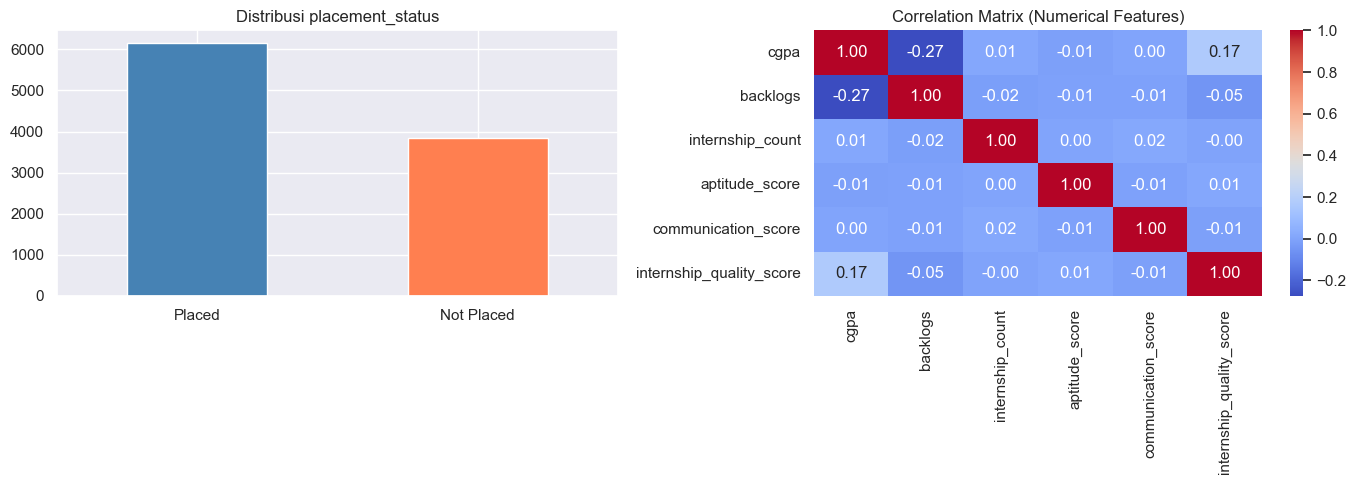

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[SETTING['TARGET']].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white'
)
axes[0].set_title(f'Distribusi {SETTING["TARGET"]}')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_xlabel('')

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1])
axes[1].set_title('Correlation Matrix (Numerical Features)')

plt.tight_layout()
plt.show()

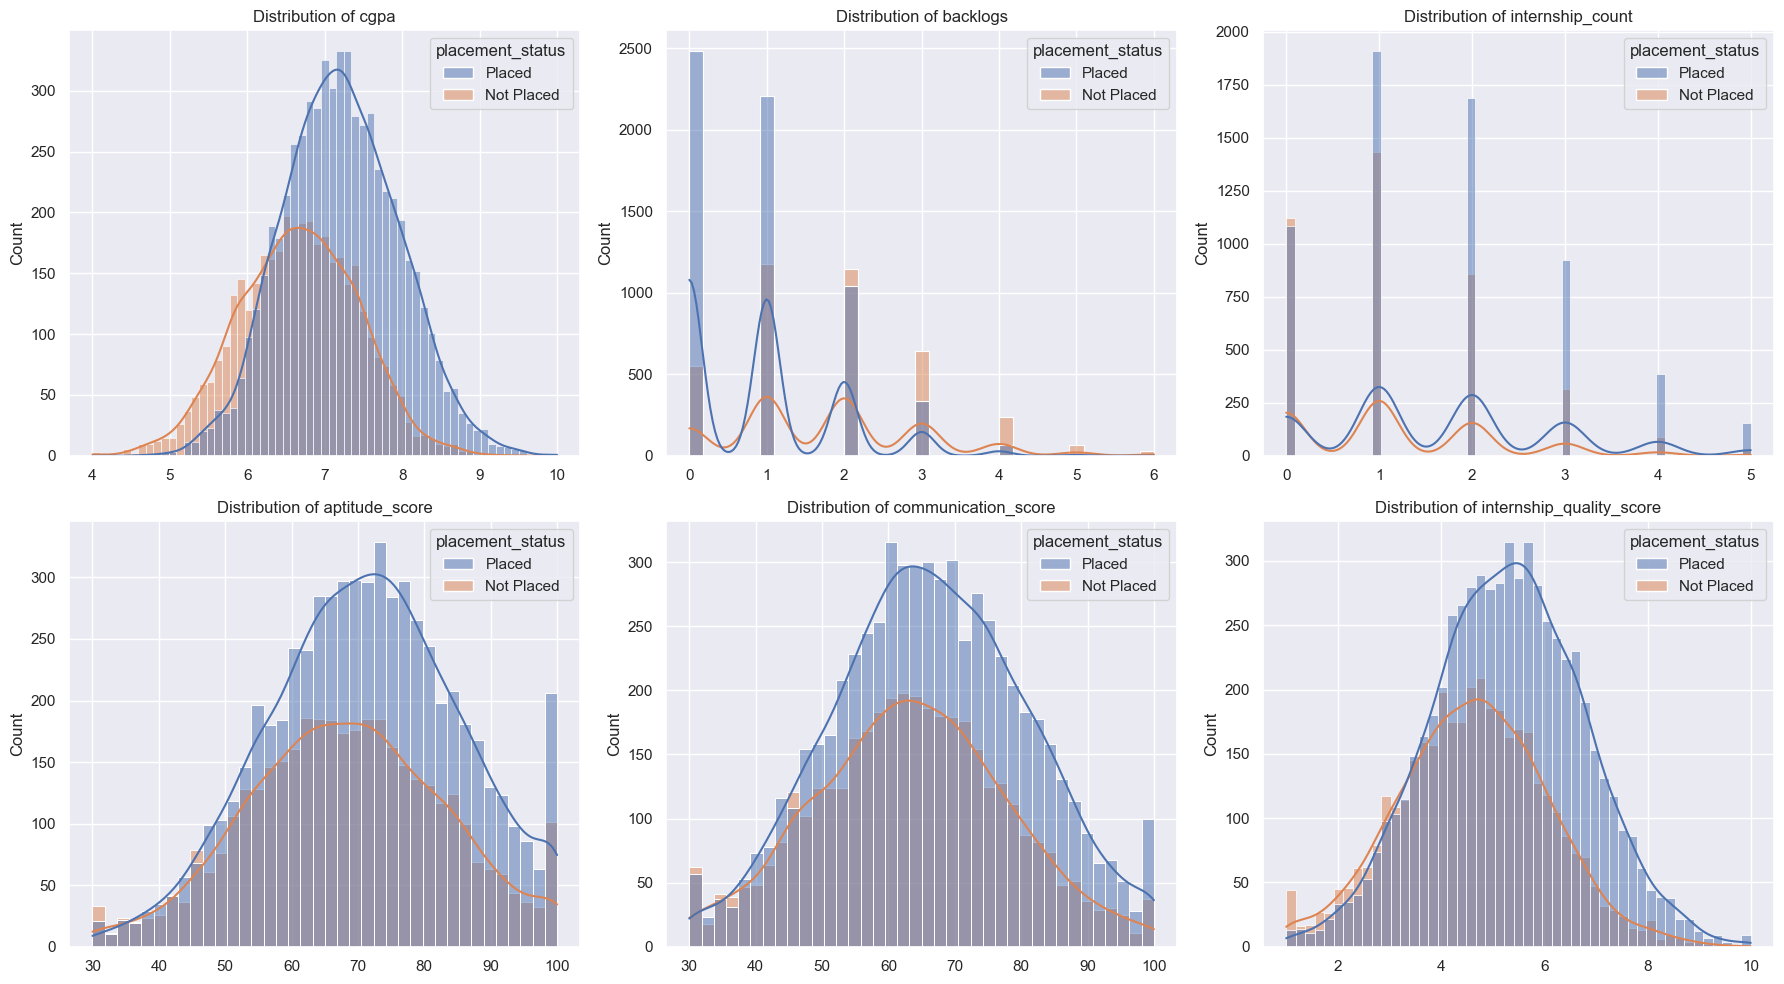

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for j, col in enumerate(num_cols):
    ax = axes[j // 3][j % 3]
    sns.histplot(data=df, x=col, hue=SETTING['TARGET'], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

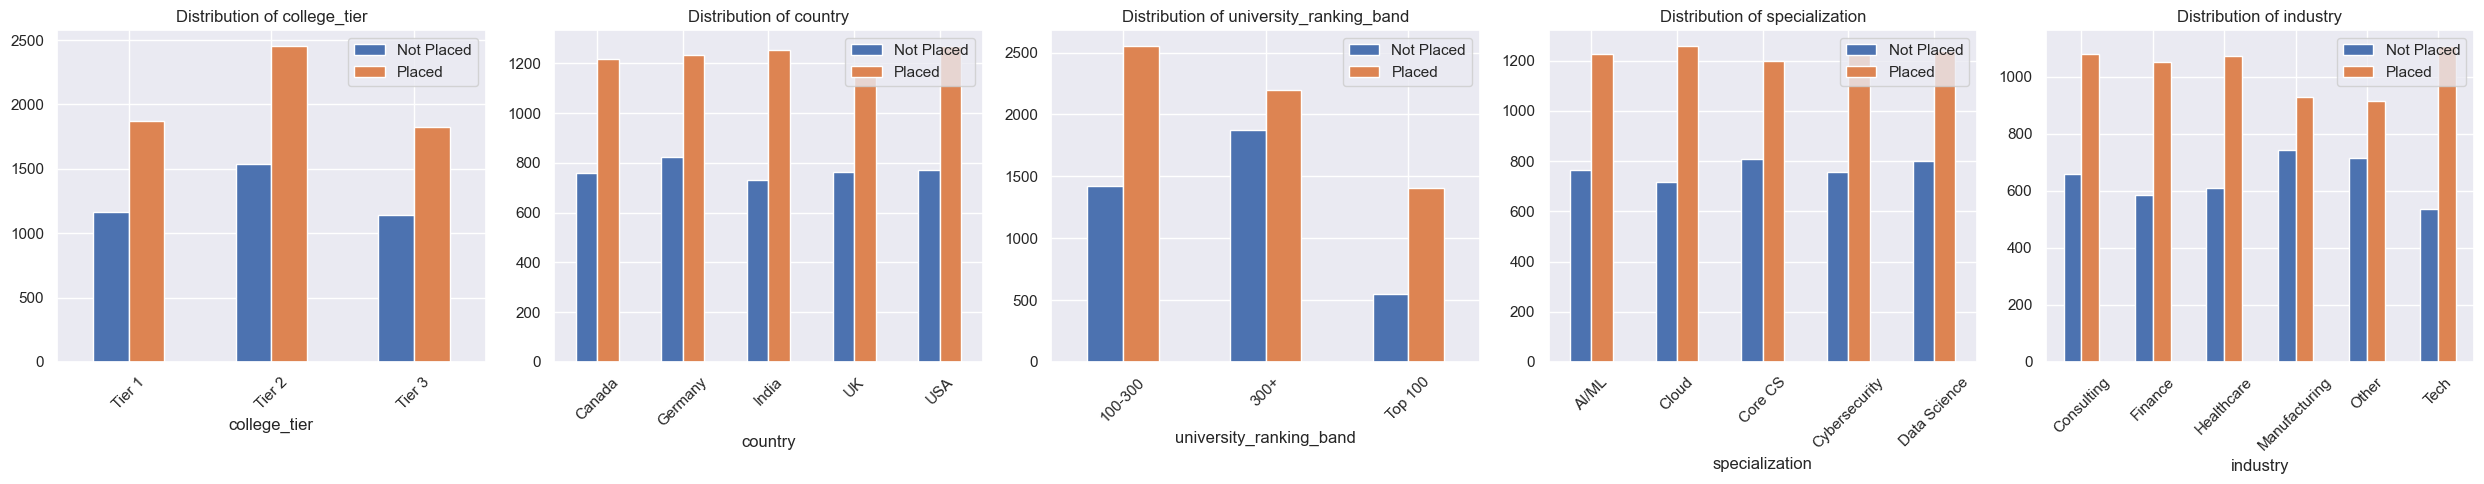

In [9]:
cat_cols = df.select_dtypes(include='object').columns.drop(SETTING['TARGET']).tolist()
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 5))

for j, col in enumerate(cat_cols):
    val_counts = df.groupby([col, SETTING['TARGET']]).size().unstack(fill_value=0)
    val_counts.plot(kind='bar', ax=axes[j], edgecolor='white')
    axes[j].set_title(f'Distribution of {col}')
    axes[j].tick_params(axis='x', rotation=45)
    axes[j].legend(title='')

plt.tight_layout()
plt.show()

# **Preprocessing**

In [10]:
print(f'[{datetime.datetime.now()}] Preprocessing started.')

df_proc = df.copy()

# encode target: Placed=1, Not Placed=0
df_proc[SETTING['TARGET']] = (df_proc[SETTING['TARGET']] == 'Placed').astype(int)

X = df_proc.drop(columns=[SETTING['TARGET']])
y = df_proc[SETTING['TARGET']].values.reshape(-1, 1)

# one-hot encode categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True).astype(float)

INPUT_DIM = X.shape[1]
print(f'Feature dimensions after encoding: {INPUT_DIM}')

X_train, X_val, y_train, y_val = train_test_split(
    X.values, y,
    test_size=SETTING['test_size'],
    random_state=SETTING['random_state'],
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

print(f'Train: {X_train.shape}, Val: {X_val.shape}')
print(f'[{datetime.datetime.now()}] Preprocessing completed.')

[2026-03-18 19:18:32.475089] Preprocessing started.
Feature dimensions after encoding: 23
Train: (8000, 23), Val: (2000, 23)
[2026-03-18 19:18:32.544270] Preprocessing completed.


In [11]:
X_train

array([[ 0.83052491, -0.21344508, -1.24590291, ..., -0.44996117,
        -0.43927386, -0.44190344],
       [-0.96688796, -0.21344508,  0.42560862, ..., -0.44996117,
        -0.43927386,  2.26293781],
       [-0.51892683, -1.08199066, -0.41014714, ..., -0.44996117,
        -0.43927386, -0.44190344],
       ...,
       [-2.52403952,  0.65510051,  0.42560862, ...,  2.222414  ,
        -0.43927386, -0.44190344],
       [ 1.33061586, -1.08199066, -1.24590291, ..., -0.44996117,
         2.27648418, -0.44190344],
       [-2.3534326 , -0.21344508, -0.41014714, ...,  2.222414  ,
        -0.43927386, -0.44190344]], shape=(8000, 23))

# **Experiment Setup**

In [12]:
def build_model(hidden_units, activation='relu', l1=0.0, l2=0.0, seed=42):
    model = FFNN()
    init  = initialize_uniform(-0.5, 0.5, seed=seed)
    for i, units in enumerate(hidden_units):
        kwargs = dict(activation=activation, weight_initializer=init, l1=l1, l2=l2)
        if i == 0:
            kwargs['input_dim'] = INPUT_DIM
        model.add(Dense(units, **kwargs))
    model.add(Dense(1, activation='sigmoid',
                    weight_initializer=initialize_uniform(-0.5, 0.5, seed=seed)))
    model.compile(loss='bce')
    return model


def evaluate(model, X, y):
    y_pred = (model.predict(X) >= 0.5).astype(int)
    return accuracy_score(y, y_pred), f1_score(y, y_pred)


def plot_loss_curves(histories, labels, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for h, label in zip(histories, labels):
        ax1.plot(h['train_loss'], label=label)
        if h['val_loss']:
            ax2.plot(h['val_loss'], label=label)
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax2.set_title('Validation Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    if title:
        plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def compare_distributions(models, labels, layer_idx=0):
    n    = len(models)
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 8))
    if n == 1:
        axes = axes.reshape(2, 1)
    for i, (model, label) in enumerate(zip(models, labels)):
        layer = model.layer_list[layer_idx]
        axes[0, i].hist(layer.W.flatten(), bins=30, color='steelblue', edgecolor='white')
        axes[0, i].set_title(f'{label}\nWeights (Layer {layer_idx})')
        axes[0, i].set_xlabel('Weight value')
        if layer.dW is not None:
            axes[1, i].hist(layer.dW.flatten(), bins=30, color='coral', edgecolor='white')
        axes[1, i].set_title(f'{label}\nGradients (Layer {layer_idx})')
        axes[1, i].set_xlabel('Gradient value')
    plt.tight_layout()
    plt.show()

# **1. Hyperparameter Analysis**

## **1.1 Pengaruh Depth dan Width**

### Width Variation (depth = 2 hidden layers)

In [13]:
print(f'[{datetime.datetime.now()}] Width experiments started.')

width_configs = [
    ([16, 16],   'Width-16'),
    ([64, 64],   'Width-64'),
    ([128, 128], 'Width-128'),
]

width_models, width_histories, width_labels = [], [], []
for units, label in width_configs:
    print(f'  Training {label}...')
    model   = build_model(units, activation='relu')
    history = model.fit(
        X_train, y_train, X_val=X_val, y_val=y_val,
        batch_size=SETTING['batch_size'],
        learning_rate=SETTING['learning_rate'],
        epoch=SETTING['epochs'], verbose=0
    )
    width_models.append(model)
    width_histories.append(history)
    width_labels.append(label)

print(f'[{datetime.datetime.now()}] Width experiments completed.')

[2026-03-18 19:18:32.589410] Width experiments started.
  Training Width-16...
  Training Width-64...
  Training Width-128...
[2026-03-18 19:18:47.495567] Width experiments completed.


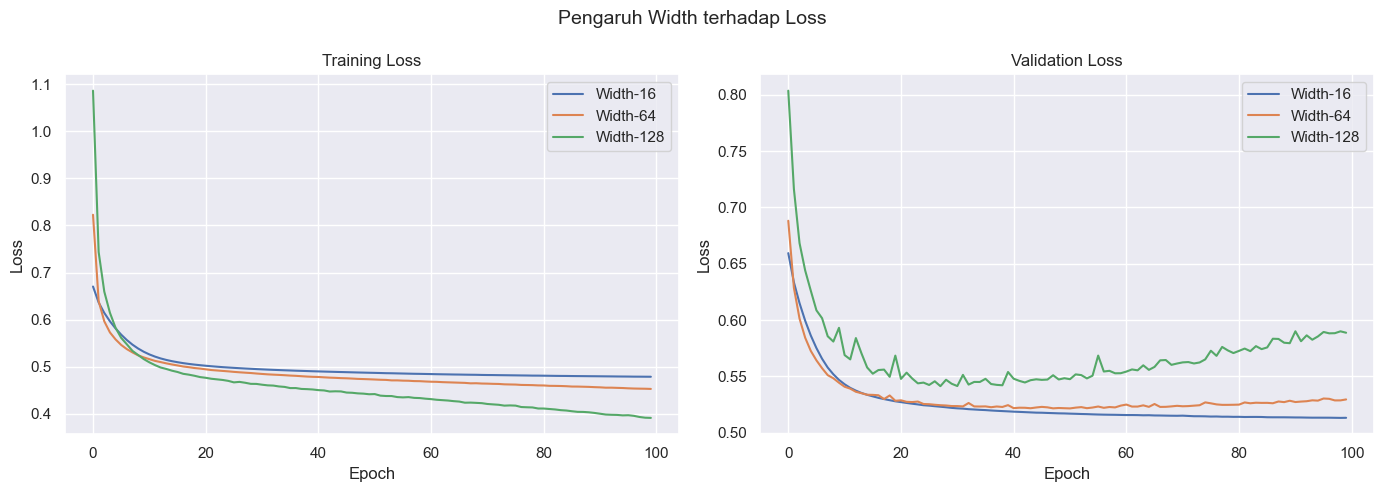

In [14]:
plot_loss_curves(width_histories, width_labels, title='Pengaruh Width terhadap Loss')

In [15]:
rows = []
for model, label in zip(width_models, width_labels):
    acc, f1 = evaluate(model, X_val, y_val)
    rows.append({'Config': label, 'Accuracy': round(acc, 4), 'F1 Score': round(f1, 4)})
pd.DataFrame(rows).set_index('Config')

,Accuracy,F1 Score
Config,,
Width-16,0.7490,0.8019
Width-64,0.7450,0.8016
Width-128,0.7205,0.7791


### Depth Variation (width = 32 per hidden layer)

In [16]:
print(f'[{datetime.datetime.now()}] Depth experiments started.')

depth_configs = [
    ([32],         'Depth-1'),
    ([32, 32],     'Depth-2'),
    ([32, 32, 32], 'Depth-3'),
]

depth_models, depth_histories, depth_labels = [], [], []
for units, label in depth_configs:
    print(f'  Training {label}...')
    model   = build_model(units, activation='relu')
    history = model.fit(
        X_train, y_train, X_val=X_val, y_val=y_val,
        batch_size=SETTING['batch_size'],
        learning_rate=SETTING['learning_rate'],
        epoch=SETTING['epochs'], verbose=0
    )
    depth_models.append(model)
    depth_histories.append(history)
    depth_labels.append(label)

print(f'[{datetime.datetime.now()}] Depth experiments completed.')

[2026-03-18 19:18:48.108163] Depth experiments started.
  Training Depth-1...
  Training Depth-2...
  Training Depth-3...
[2026-03-18 19:18:58.172972] Depth experiments completed.


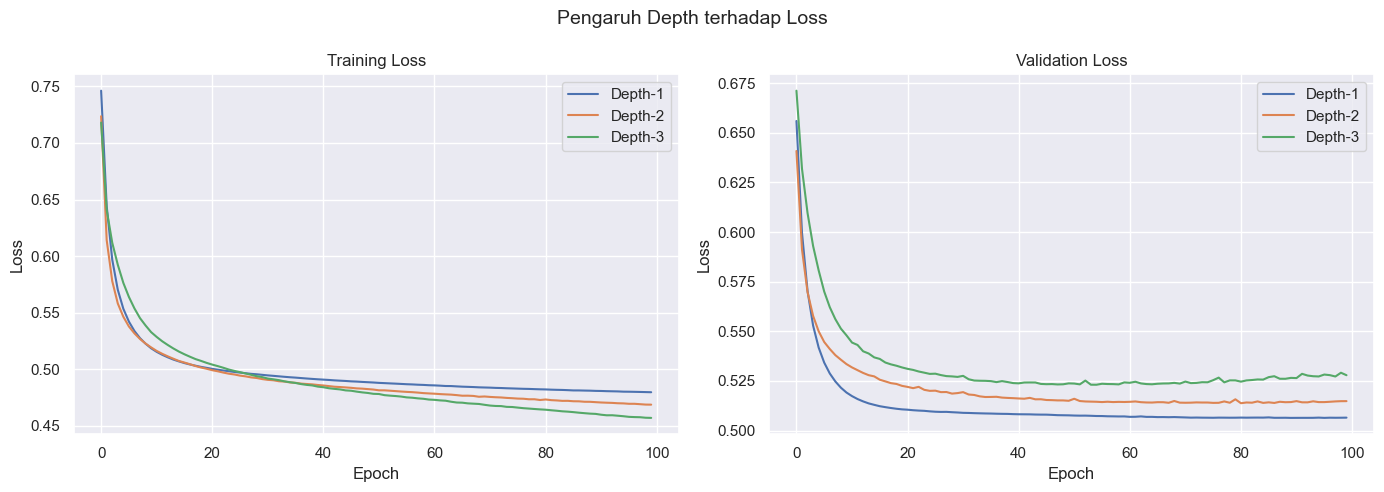

In [17]:
plot_loss_curves(depth_histories, depth_labels, title='Pengaruh Depth terhadap Loss')

In [18]:
rows = []
for model, label in zip(depth_models, depth_labels):
    acc, f1 = evaluate(model, X_val, y_val)
    rows.append({'Config': label, 'Accuracy': round(acc, 4), 'F1 Score': round(f1, 4)})
pd.DataFrame(rows).set_index('Config')

,Accuracy,F1 Score
Config,,
Depth-1,0.7445,0.8002
Depth-2,0.7410,0.7965
Depth-3,0.7375,0.7945


## **1.2 Pengaruh Fungsi Aktivasi**

In [19]:
print(f'[{datetime.datetime.now()}] Activation experiments started.')

activation_configs = ['linear', 'relu', 'sigmoid', 'tanh', 'leaky_relu', 'swish']

act_models, act_histories, act_labels = [], [], []
for act in activation_configs:
    print(f'  Training activation={act}...')
    model   = build_model([32, 32, 32], activation=act)
    history = model.fit(
        X_train, y_train, X_val=X_val, y_val=y_val,
        batch_size=SETTING['batch_size'],
        learning_rate=SETTING['learning_rate'],
        epoch=SETTING['epochs'], verbose=0
    )
    act_models.append(model)
    act_histories.append(history)
    act_labels.append(act)

print(f'[{datetime.datetime.now()}] Activation experiments completed.')

[2026-03-18 19:18:58.604641] Activation experiments started.
  Training activation=linear...
  Training activation=relu...
  Training activation=sigmoid...
  Training activation=tanh...
  Training activation=leaky_relu...
  Training activation=swish...
[2026-03-18 19:19:32.595042] Activation experiments completed.


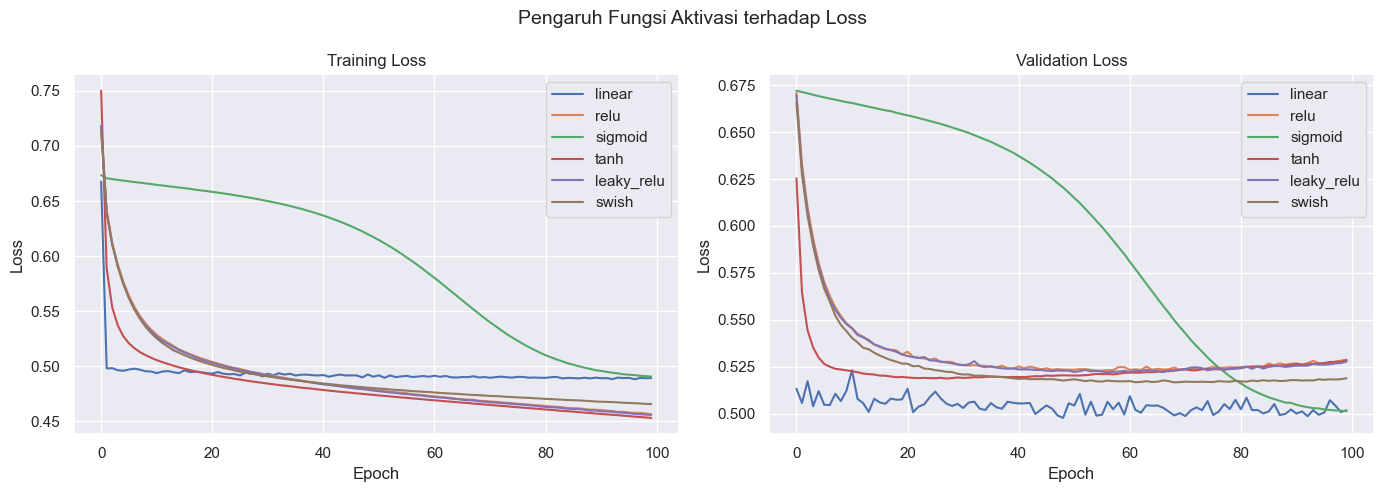

In [20]:
plot_loss_curves(act_histories, act_labels, title='Pengaruh Fungsi Aktivasi terhadap Loss')

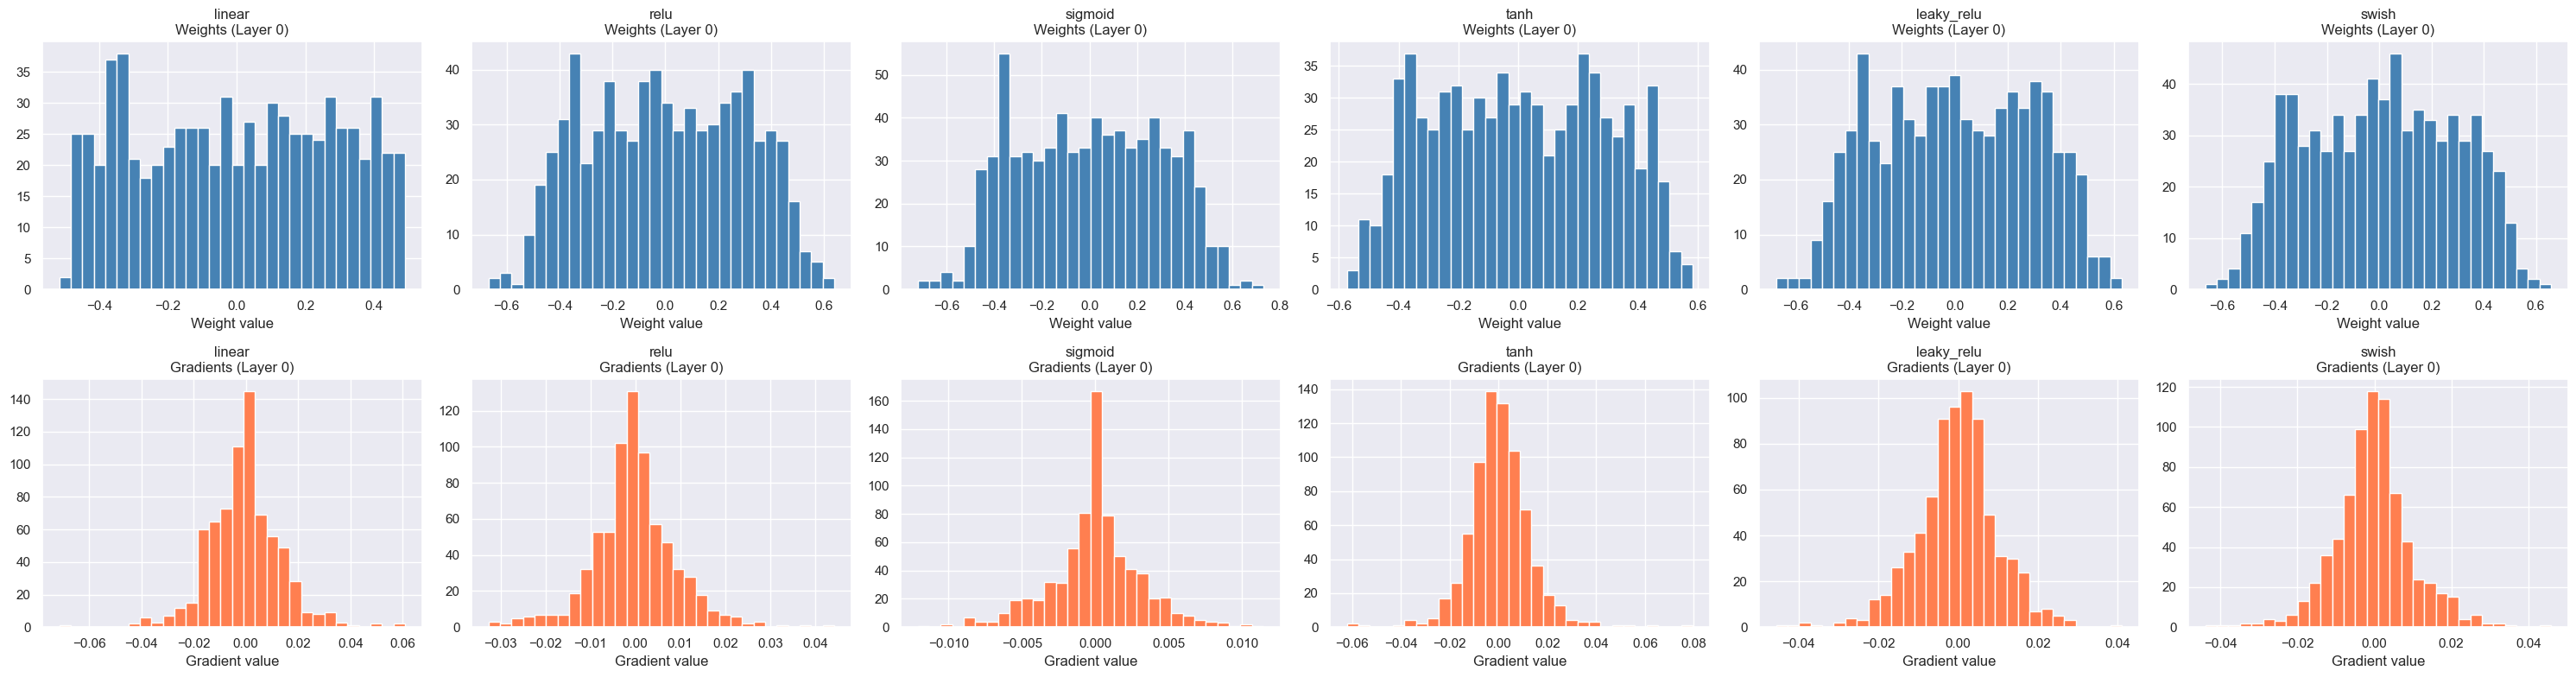

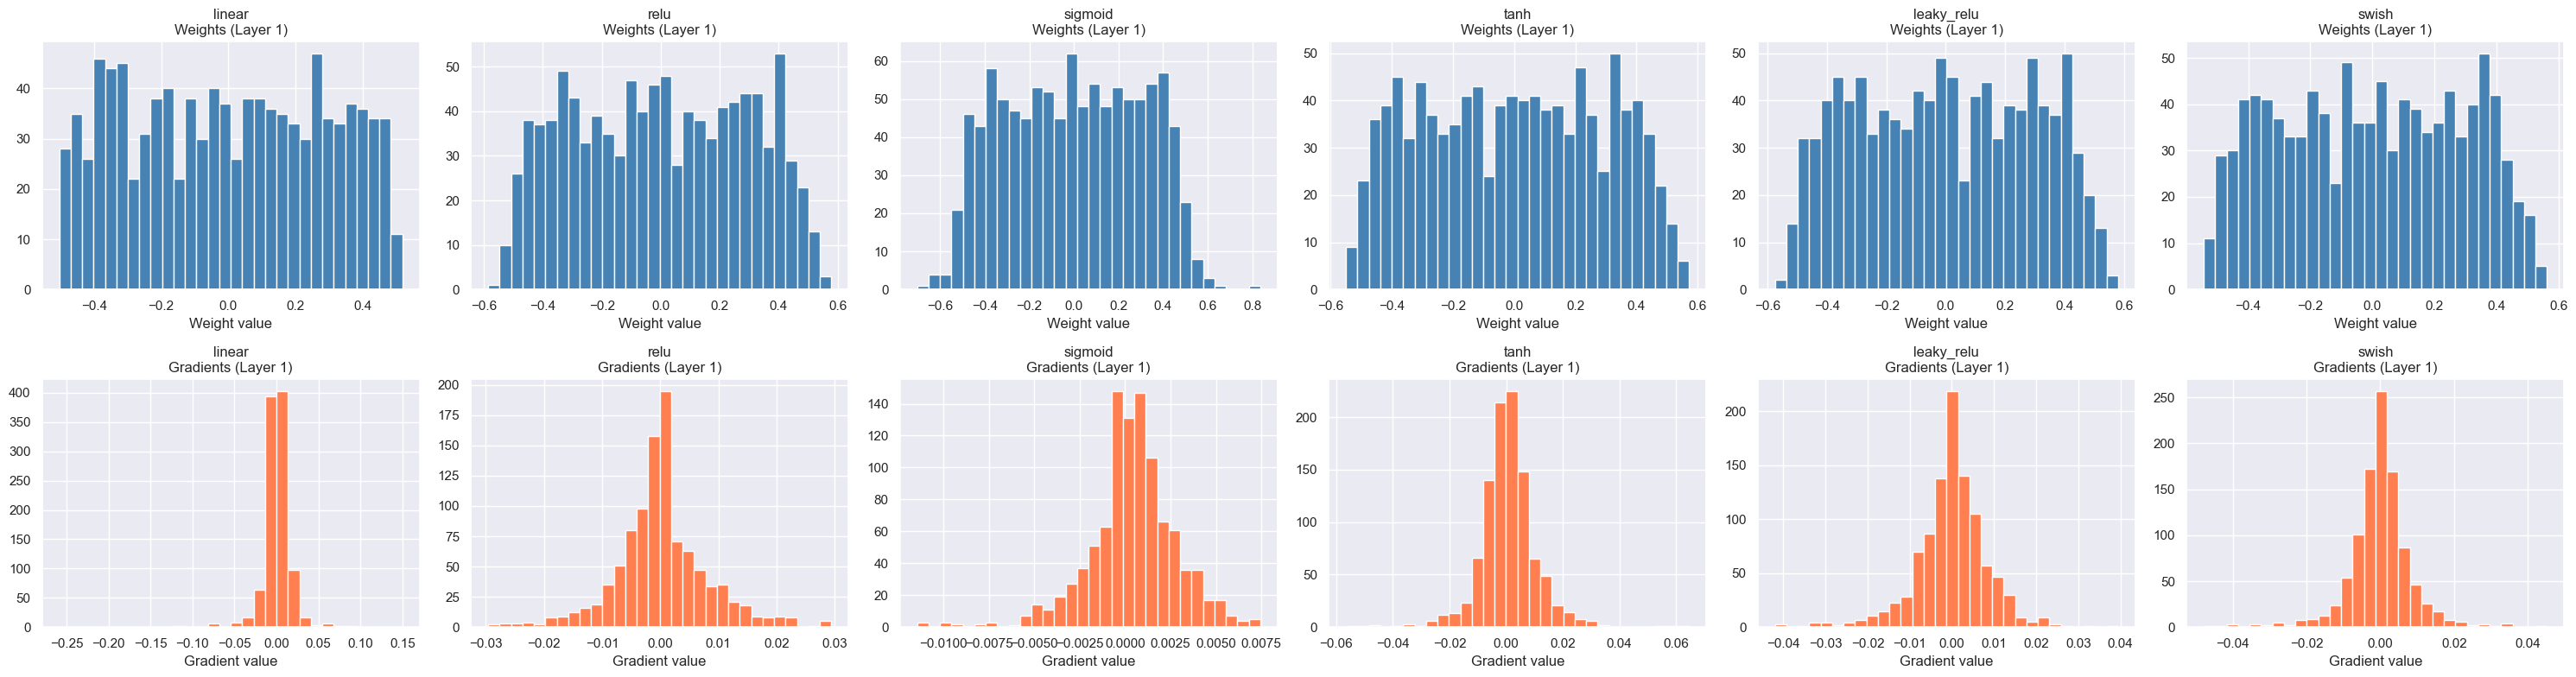

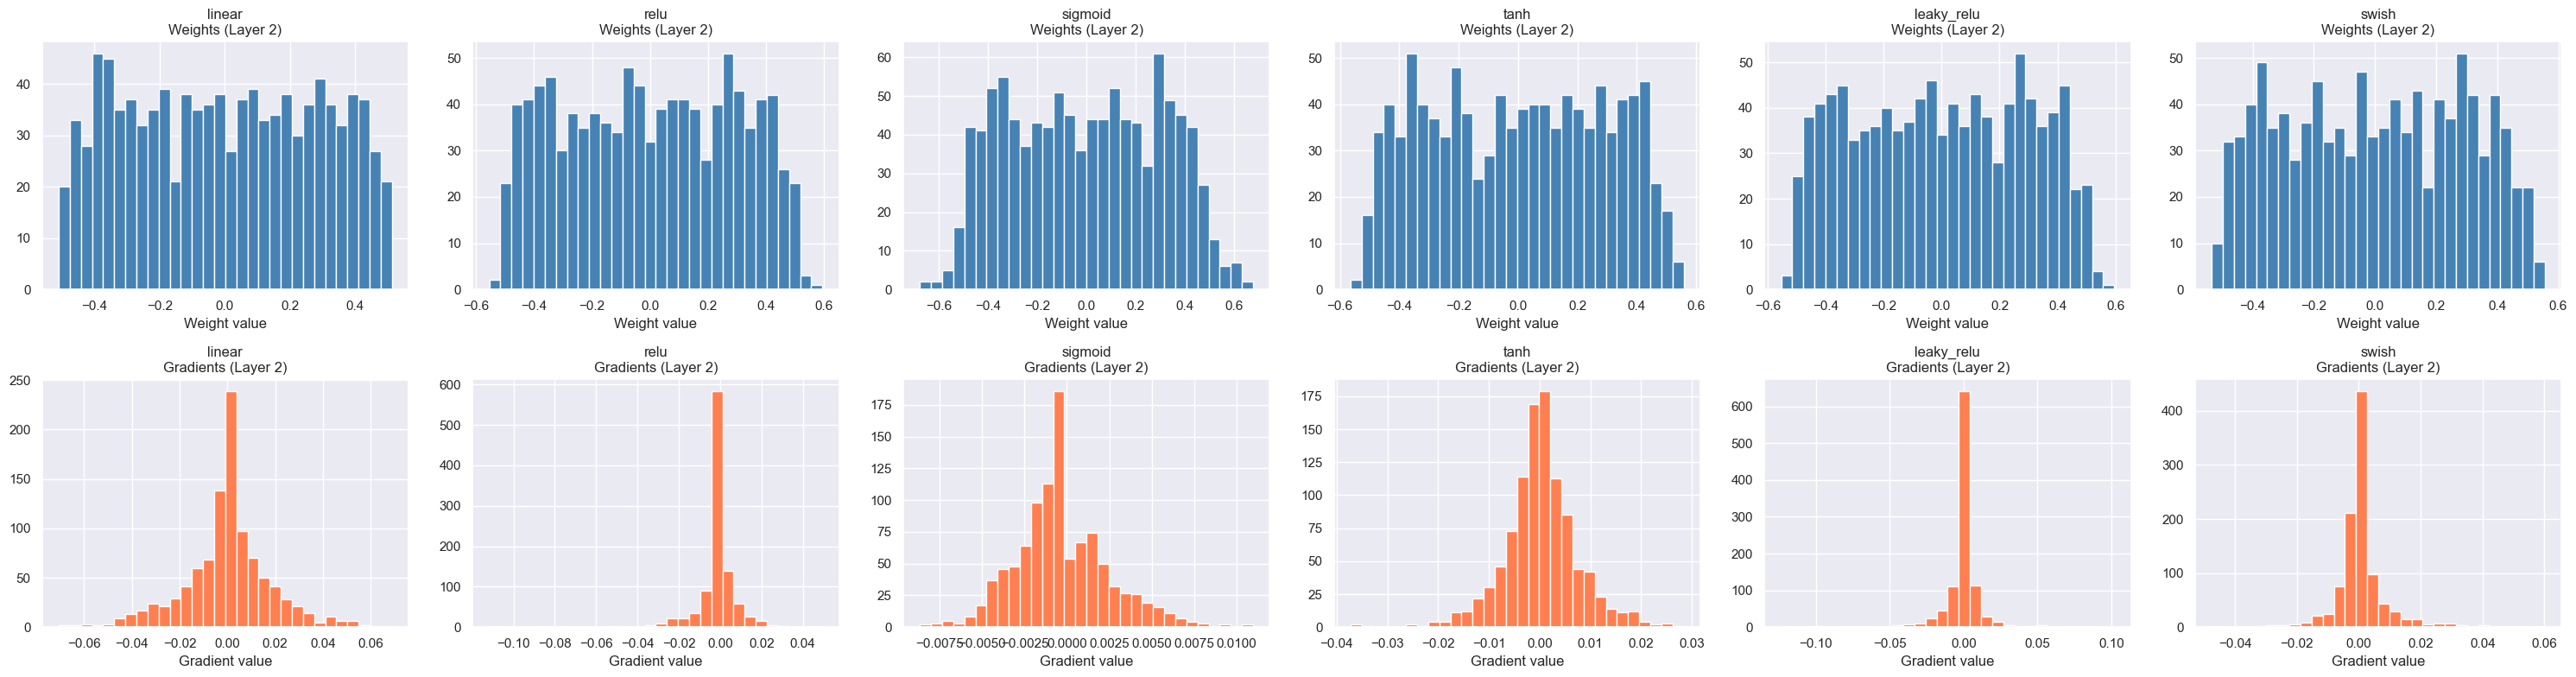

In [21]:
compare_distributions(act_models, act_labels, layer_idx=0)
compare_distributions(act_models, act_labels, layer_idx=1)
compare_distributions(act_models, act_labels, layer_idx=2)

In [22]:
rows = []
for model, label in zip(act_models, act_labels):
    acc, f1 = evaluate(model, X_val, y_val)
    rows.append({'Activation': label, 'Accuracy': round(acc, 4), 'F1 Score': round(f1, 4)})
pd.DataFrame(rows).set_index('Activation')

,Accuracy,F1 Score
Activation,,
linear,0.7510,0.8061
relu,0.7375,0.7922
sigmoid,0.7545,0.8089
tanh,0.7400,0.7959
leaky_relu,0.7400,0.7984
swish,0.7390,0.7942


## **1.3 Pengaruh Learning Rate**

In [23]:
print(f'[{datetime.datetime.now()}] Learning rate experiments started.')

lr_configs = [0.001, 0.01, 0.1]

lr_models, lr_histories, lr_labels = [], [], []
for lr in lr_configs:
    print(f'  Training lr={lr}...')
    model   = build_model([32, 32], activation='relu')
    history = model.fit(
        X_train, y_train, X_val=X_val, y_val=y_val,
        batch_size=SETTING['batch_size'],
        learning_rate=lr,
        epoch=SETTING['epochs'], verbose=0
    )
    lr_models.append(model)
    lr_histories.append(history)
    lr_labels.append(f'lr={lr}')

print(f'[{datetime.datetime.now()}] Learning rate experiments completed.')

[2026-03-18 19:19:43.282010] Learning rate experiments started.
  Training lr=0.001...
  Training lr=0.01...
  Training lr=0.1...
[2026-03-18 19:19:53.509438] Learning rate experiments completed.


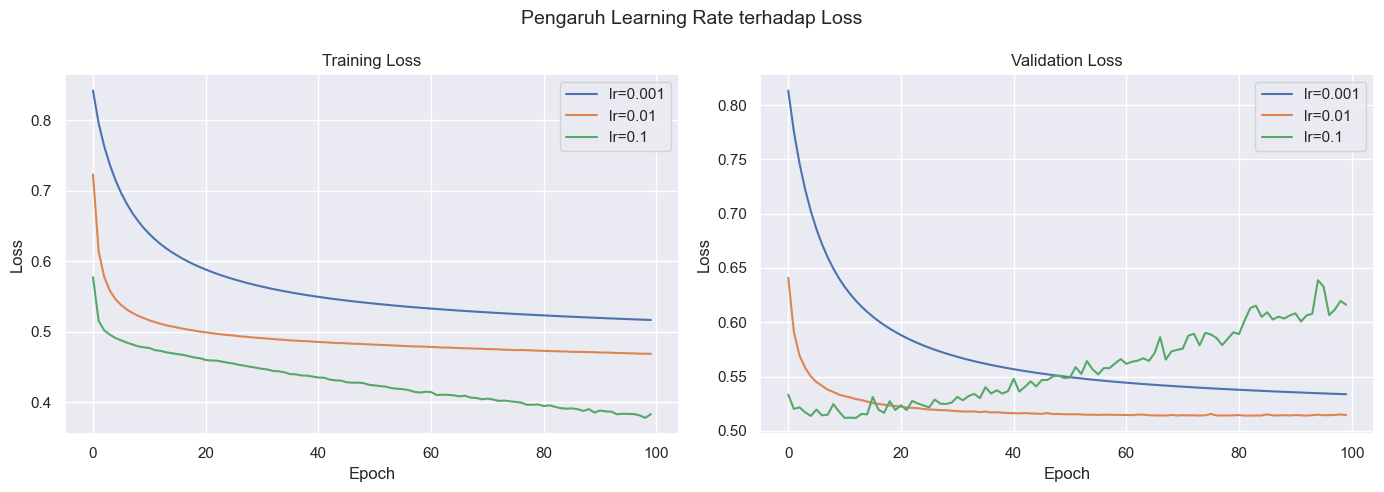

In [24]:
plot_loss_curves(lr_histories, lr_labels, title='Pengaruh Learning Rate terhadap Loss')

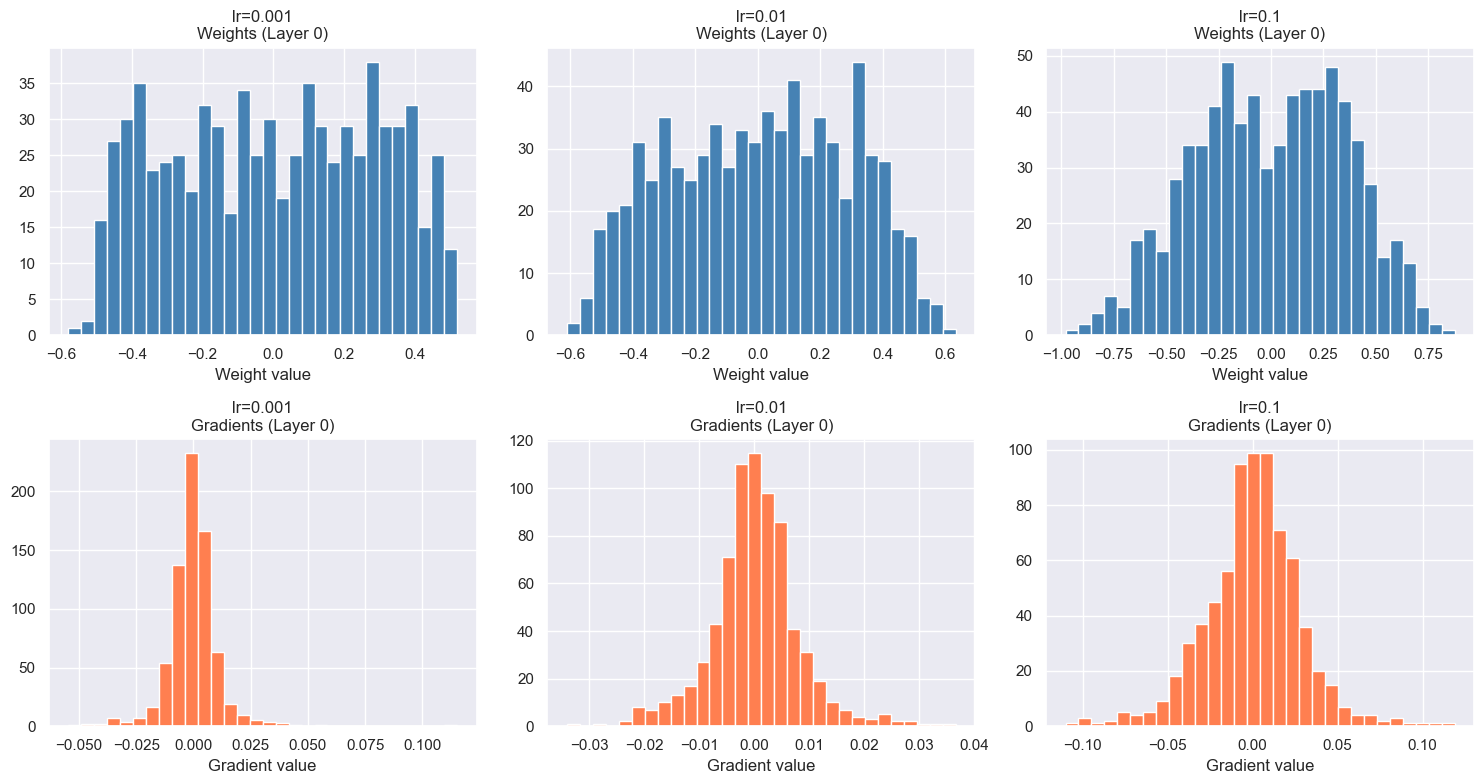

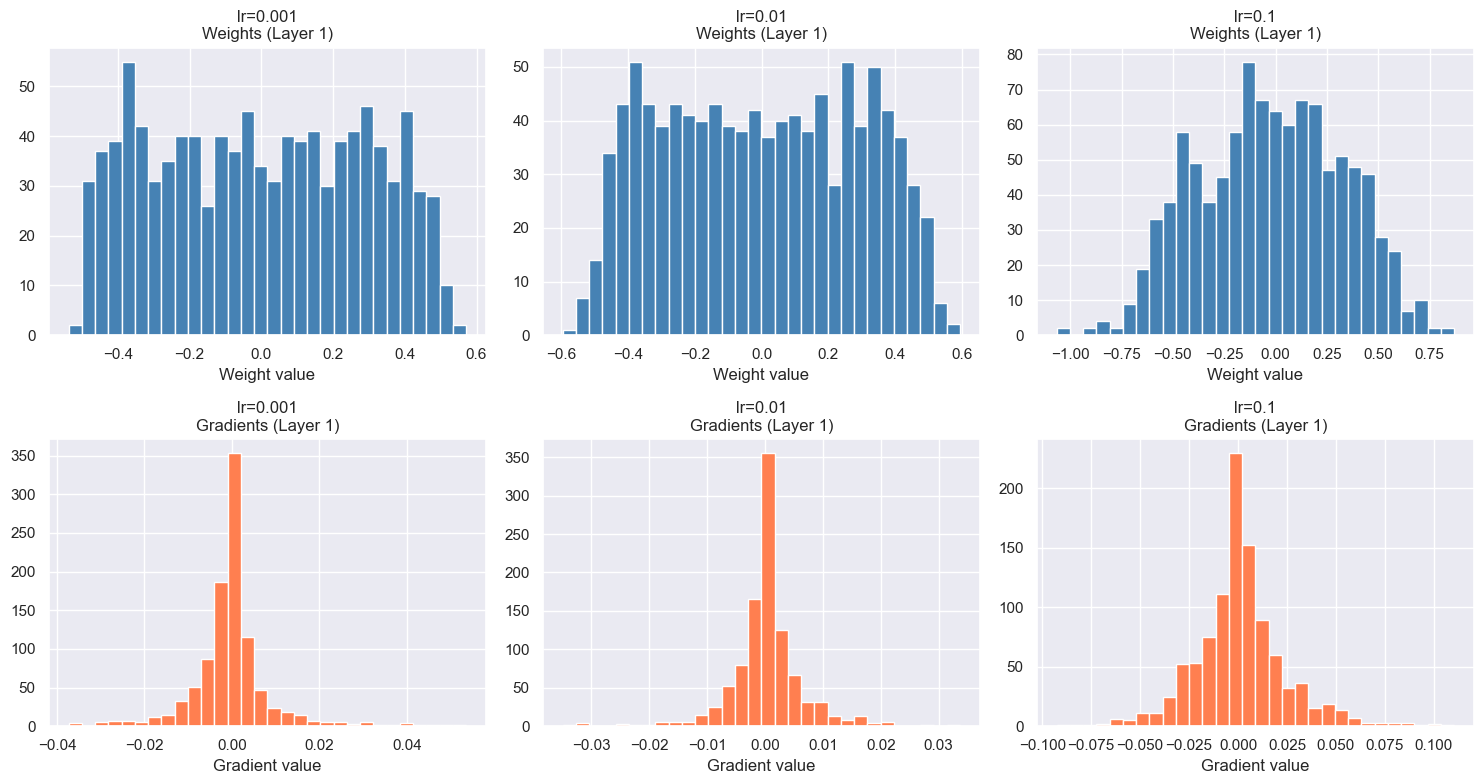

In [25]:
compare_distributions(lr_models, lr_labels, layer_idx=0)
compare_distributions(lr_models, lr_labels, layer_idx=1)


In [26]:
rows = []
for model, label in zip(lr_models, lr_labels):
    acc, f1 = evaluate(model, X_val, y_val)
    rows.append({'Learning Rate': label, 'Accuracy': round(acc, 4), 'F1 Score': round(f1, 4)})
pd.DataFrame(rows).set_index('Learning Rate')

,Accuracy,F1 Score
Learning Rate,,
lr=0.001,0.7300,0.7912
lr=0.01,0.7440,0.8012
lr=0.1,0.7215,0.7753


## **1.4 Pengaruh Inisialisasi Bobot**

In [27]:
from initializers import initialize_zero, initialize_random, initialize_xavier_uniform, initialize_he

init_configs = [
    (initialize_zero(),                       'Zero Init'),
    (initialize_uniform(-0.5, 0.5, seed=42),  'Uniform Init [-0.5, 0.5]'),
    (initialize_random(0.0, 0.1, seed=42),    'Gaussian Init (μ=0, σ²=0.1)'),
    (initialize_xavier_uniform(seed=42),      'Xavier Uniform'),
    (initialize_he(seed=42),                  'He Normal'),
]

init_models, init_histories, init_labels = [], [], []
for weight_init, label in init_configs:
    print(f'\n── {label} ──')
    model = FFNN()
    model.add(Dense(32, activation='relu', weight_initializer=weight_init, input_dim=INPUT_DIM))
    model.add(Dense(32, activation='relu', weight_initializer=weight_init))
    model.add(Dense(1,  activation='sigmoid', weight_initializer=weight_init))
    model.compile(loss='bce')
    history = model.fit(
        X_train, y_train, X_val=X_val, y_val=y_val,
        batch_size=SETTING['batch_size'],
        learning_rate=SETTING['learning_rate'],
        epoch=SETTING['epochs'], verbose=1
    )
    init_models.append(model)
    init_histories.append(history)
    init_labels.append(label)


── Zero Init ──
Epoch 100/100 [==============================] loss: 0.6664 - val_loss: 0.6662

── Uniform Init [-0.5, 0.5] ──
Epoch 100/100 [==============================] loss: 0.4686 - val_loss: 0.5148

── Gaussian Init (μ=0, σ²=0.1) ──
Epoch 100/100 [==============================] loss: 0.4742 - val_loss: 0.5108

── Xavier Uniform ──
Epoch 100/100 [==============================] loss: 0.4681 - val_loss: 0.5094

── He Normal ──
Epoch 100/100 [==============================] loss: 0.4749 - val_loss: 0.5094


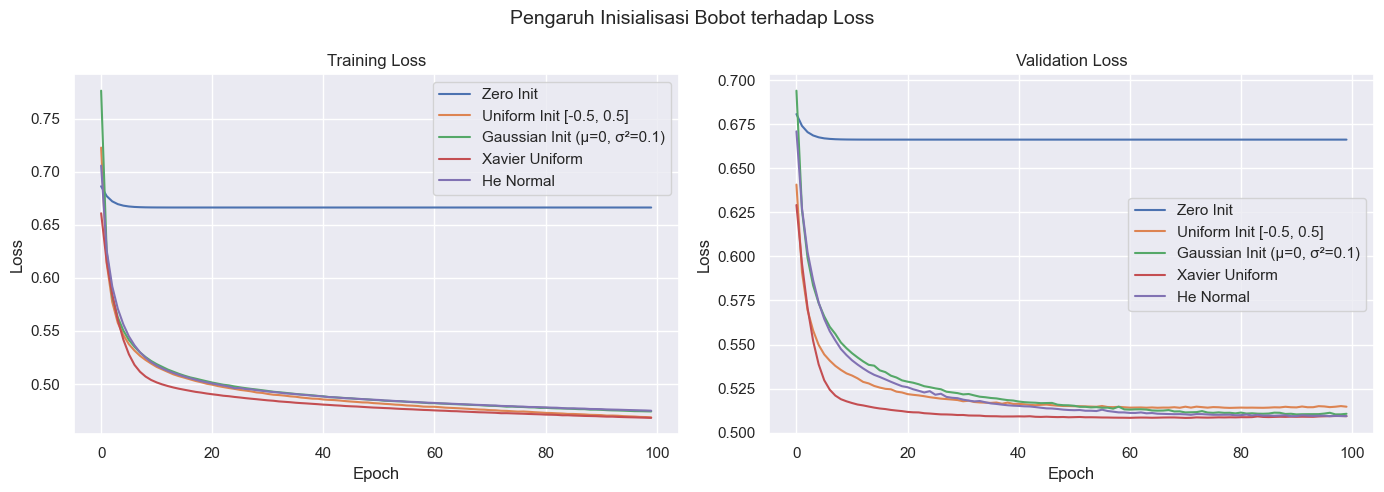

In [28]:
plot_loss_curves(init_histories, init_labels, title='Pengaruh Inisialisasi Bobot terhadap Loss')

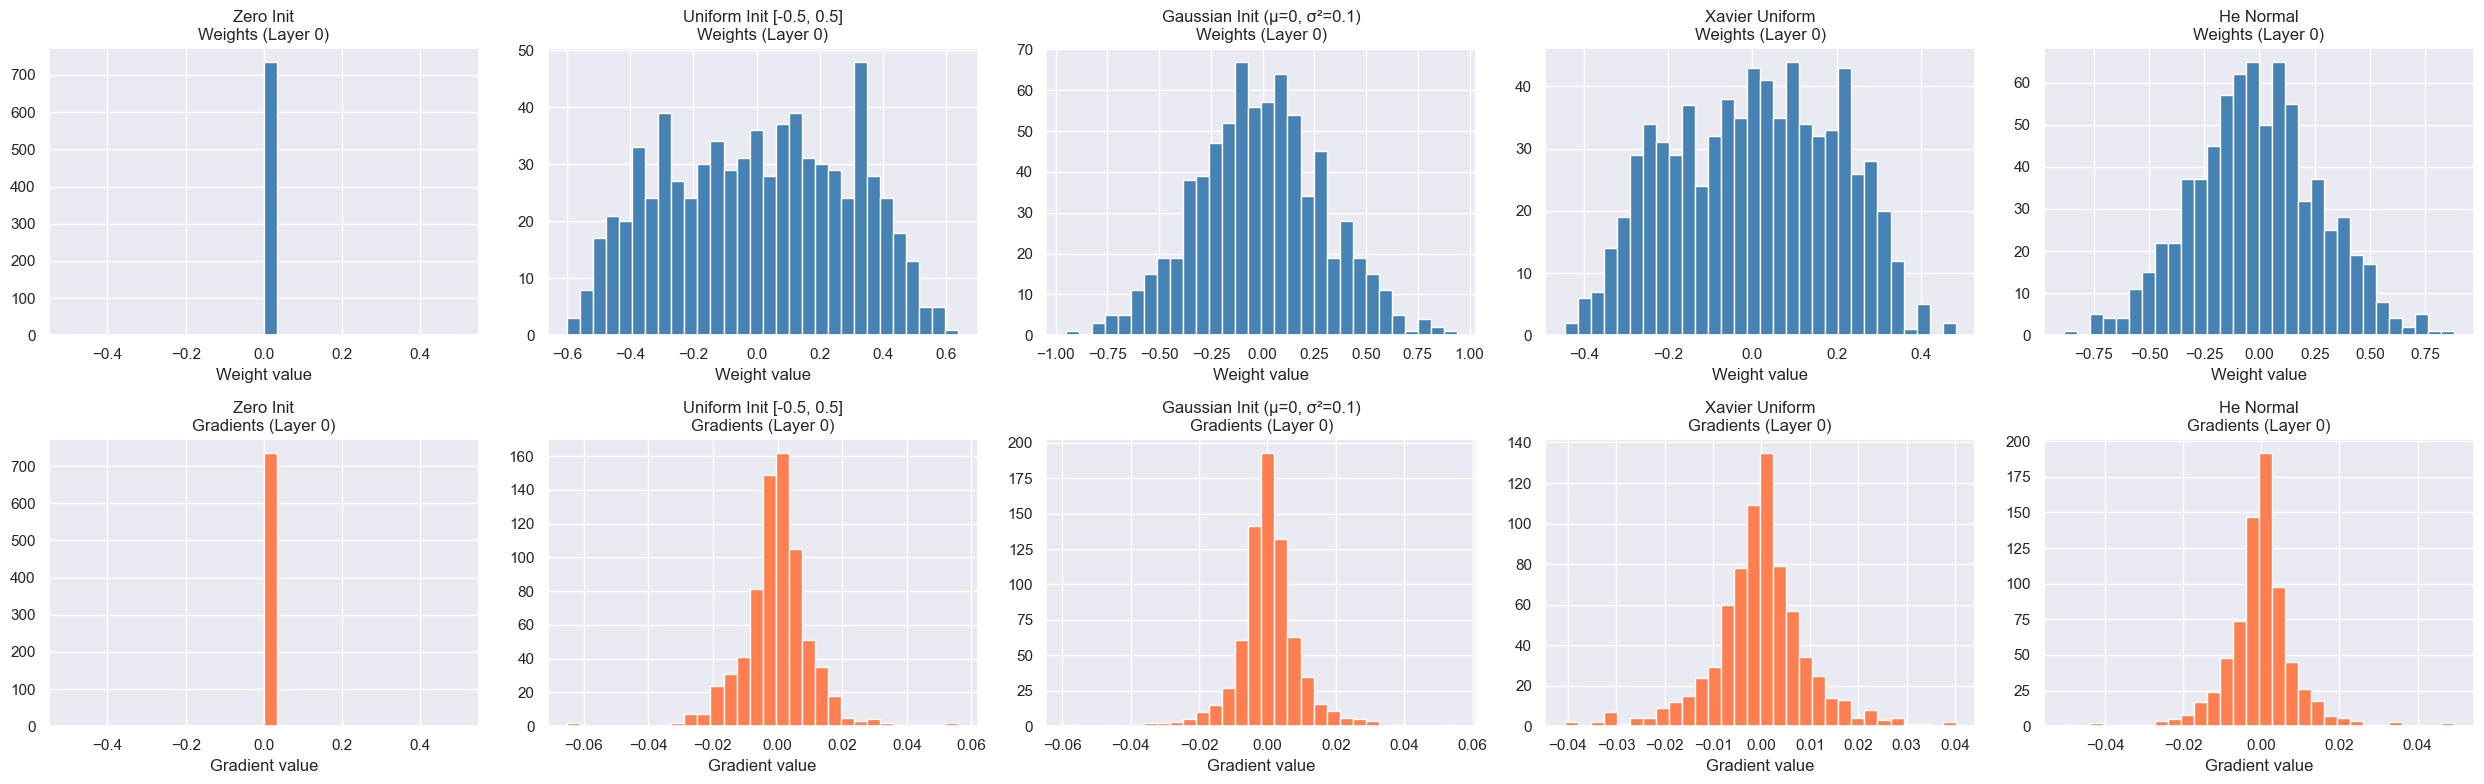

In [29]:
compare_distributions(init_models, init_labels, layer_idx=0)

In [30]:
rows = []
for model, label in zip(init_models, init_labels):
    acc, f1 = evaluate(model, X_val, y_val)
    rows.append({'Initializer': label, 'Accuracy': round(acc, 4), 'F1 Score': round(f1, 4)})
pd.DataFrame(rows).set_index('Initializer')

,Accuracy,F1 Score
Initializer,,
Zero Init,0.6155,0.7620
"Uniform Init [-0.5, 0.5]",0.7455,0.8025
"Gaussian Init (μ=0, σ²=0.1)",0.7490,0.8019
Xavier Uniform,0.7505,0.8059
He Normal,0.7525,0.8070


# **2. Pengaruh Regularisasi**

In [31]:
print(f'[{datetime.datetime.now()}] Regularization experiments started.')

reg_configs = [
    (0.0,   0.0,   'No Regularization'),
    (0.001, 0.0,   'L1 (lambda=0.001)'),
    (0.0,   0.001, 'L2 (lambda=0.001)'),
]

reg_models, reg_histories, reg_labels = [], [], []
for l1, l2, label in reg_configs:
    print(f'  Training {label}...')
    model   = build_model([32, 32], activation='relu', l1=l1, l2=l2)
    history = model.fit(
        X_train, y_train, X_val=X_val, y_val=y_val,
        batch_size=SETTING['batch_size'],
        learning_rate=SETTING['learning_rate'],
        epoch=SETTING['epochs'], verbose=0
    )
    reg_models.append(model)
    reg_histories.append(history)
    reg_labels.append(label)

print(f'[{datetime.datetime.now()}] Regularization experiments completed.')

[2026-03-18 19:20:18.869526] Regularization experiments started.
  Training No Regularization...
  Training L1 (lambda=0.001)...
  Training L2 (lambda=0.001)...
[2026-03-18 19:20:37.005307] Regularization experiments completed.


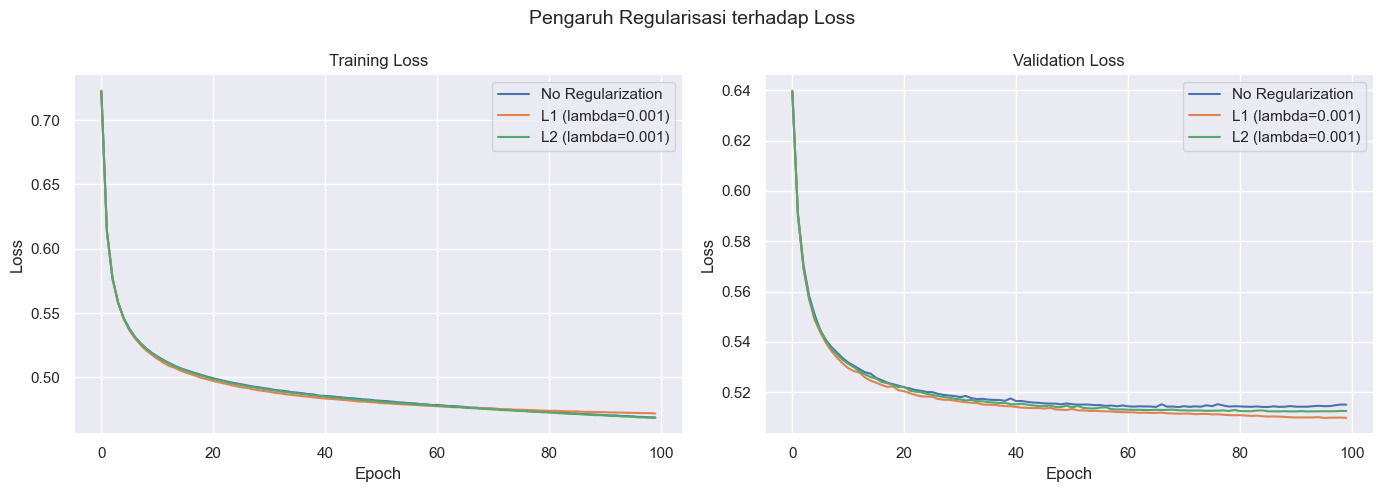

In [32]:
plot_loss_curves(reg_histories, reg_labels, title='Pengaruh Regularisasi terhadap Loss')

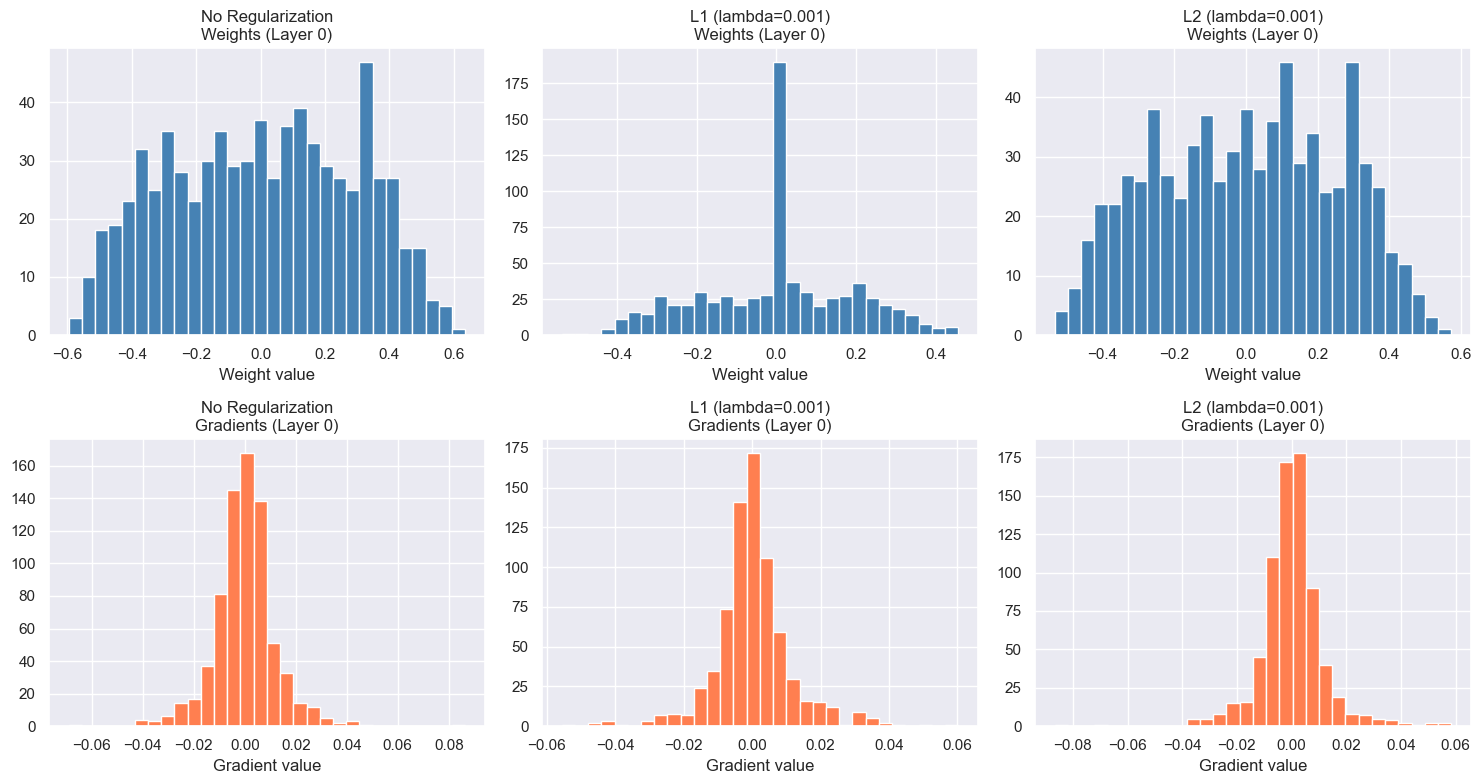

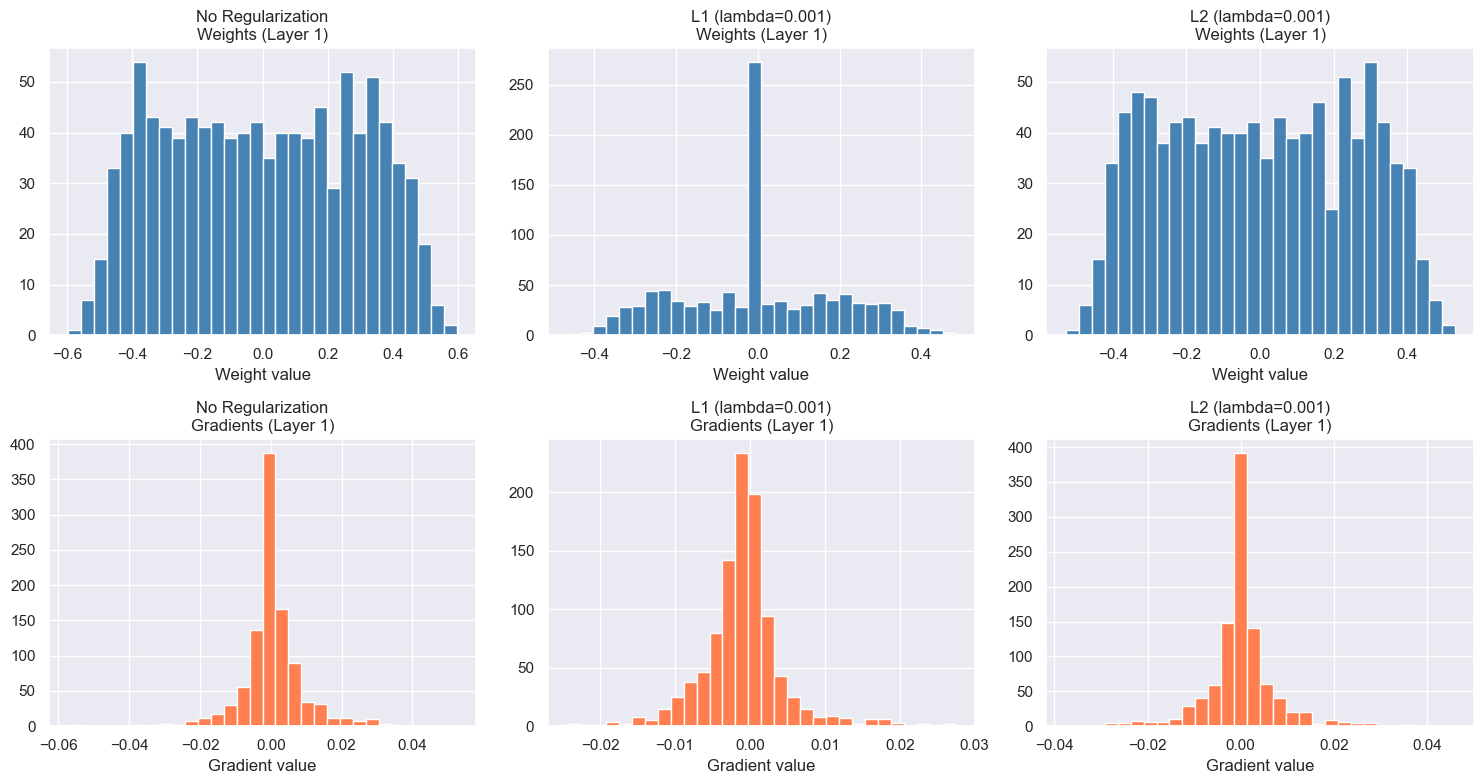

In [33]:
compare_distributions(reg_models, reg_labels, layer_idx=0)
compare_distributions(reg_models, reg_labels, layer_idx=1)


In [34]:
rows = []
for model, label in zip(reg_models, reg_labels):
    acc, f1 = evaluate(model, X_val, y_val)
    rows.append({'Regularization': label, 'Accuracy': round(acc, 4), 'F1 Score': round(f1, 4)})
pd.DataFrame(rows).set_index('Regularization')

,Accuracy,F1 Score
Regularization,,
No Regularization,0.7395,0.7946
L1 (lambda=0.001),0.7460,0.8013
L2 (lambda=0.001),0.7430,0.7995


## **3. Pengaruh Normalisasi RMSNorm**

In [35]:
from layers import RMSNorm

def build_model_rms(hidden_units, activation='relu', seed=42):
    model = FFNN()
    init = initialize_uniform(-0.5, 0.5, seed=seed)
    for i, units in enumerate(hidden_units):
        kwargs = dict(activation=activation, weight_initializer=init)
        if i == 0:
            kwargs['input_dim'] = INPUT_DIM
        model.add(Dense(units, **kwargs))
        model.add(RMSNorm(units))
    model.add(Dense(1, activation='sigmoid',
                    weight_initializer=initialize_uniform(-0.5, 0.5, seed=seed)))
    model.compile(loss='bce')
    return model


print(f'[{datetime.datetime.now()}] RMSNorm experiments started.')

rms_models, rms_histories, rms_labels = [], [], []

print('  Training without RMSNorm...')
model = build_model([32, 32], activation='relu')
history = model.fit(
    X_train, y_train, X_val=X_val, y_val=y_val,
    batch_size=SETTING['batch_size'],
    learning_rate=SETTING['learning_rate'],
    epoch=SETTING['epochs'], verbose=0
)
rms_models.append(model)
rms_histories.append(history)
rms_labels.append('Without RMSNorm')

print('  Training with RMSNorm...')
model = build_model_rms([32, 32], activation='relu')
history = model.fit(
    X_train, y_train, X_val=X_val, y_val=y_val,
    batch_size=SETTING['batch_size'],
    learning_rate=SETTING['learning_rate'],
    epoch=SETTING['epochs'], verbose=0
)
rms_models.append(model)
rms_histories.append(history)
rms_labels.append('With RMSNorm')

print(f'[{datetime.datetime.now()}] RMSNorm experiments completed.')

[2026-03-18 19:20:48.260156] RMSNorm experiments started.
  Training without RMSNorm...
  Training with RMSNorm...
[2026-03-18 19:21:21.143884] RMSNorm experiments completed.


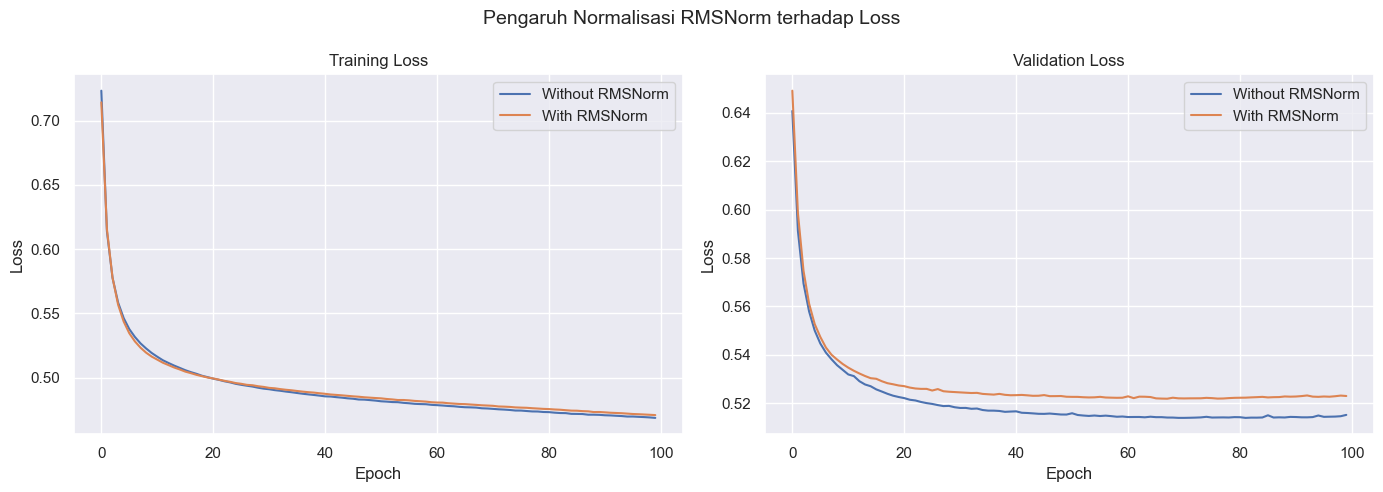

In [36]:
plot_loss_curves(rms_histories, rms_labels, title='Pengaruh Normalisasi RMSNorm terhadap Loss')

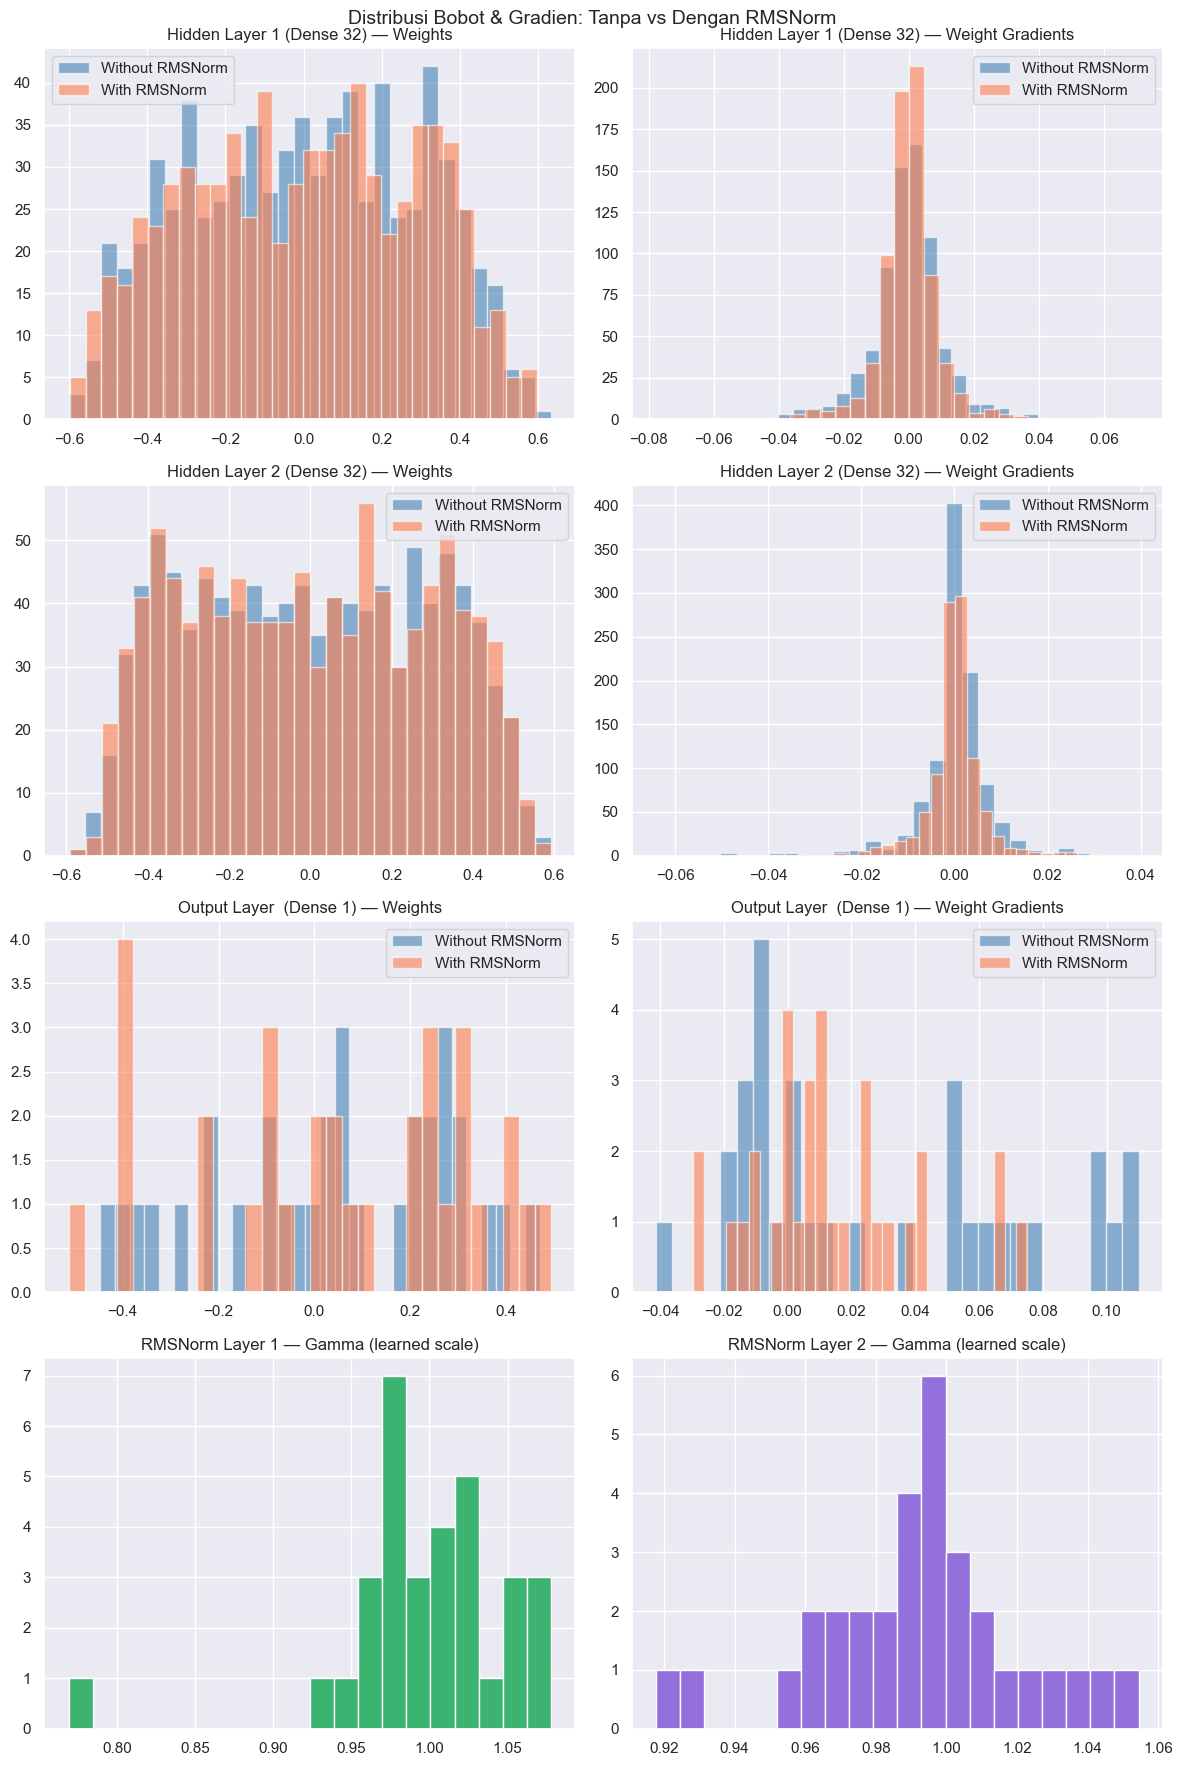

In [37]:
# Dense layer index pairs: (idx in no-RMSNorm model, idx in RMSNorm model, label)
# Without RMSNorm : [Dense32(0), Dense32(1), Dense1(2)]
# With    RMSNorm : [Dense32(0), RMSNorm(1), Dense32(2), RMSNorm(3), Dense1(4)]
dense_pairs = [
    (0, 0, 'Hidden Layer 1 (Dense 32)'),
    (1, 2, 'Hidden Layer 2 (Dense 32)'),
    (2, 4, 'Output Layer  (Dense 1)'),
]

model_no_rms = rms_models[0]
model_with_rms = rms_models[1]

fig, axes = plt.subplots(4, 2, figsize=(12, 18))

for row, (idx_no, idx_rms, title) in enumerate(dense_pairs):
    l_no  = model_no_rms.layer_list[idx_no]
    l_rms = model_with_rms.layer_list[idx_rms]

    axes[row, 0].hist(l_no.W.flatten(),  bins=30, alpha=0.6, label='Without RMSNorm', color='steelblue', edgecolor='white')
    axes[row, 0].hist(l_rms.W.flatten(), bins=30, alpha=0.6, label='With RMSNorm',    color='coral',     edgecolor='white')
    axes[row, 0].set_title(f'{title} — Weights')
    axes[row, 0].legend()

    if l_no.dW is not None and l_rms.dW is not None:
        axes[row, 1].hist(l_no.dW.flatten(),  bins=30, alpha=0.6, label='Without RMSNorm', color='steelblue', edgecolor='white')
        axes[row, 1].hist(l_rms.dW.flatten(), bins=30, alpha=0.6, label='With RMSNorm',    color='coral',     edgecolor='white')
    axes[row, 1].set_title(f'{title} — Weight Gradients')
    axes[row, 1].legend()

# RMSNorm gamma (learned scale parameter)
axes[3, 0].hist(model_with_rms.layer_list[1].gamma.flatten(), bins=20, color='mediumseagreen', edgecolor='white')
axes[3, 0].set_title('RMSNorm Layer 1 — Gamma (learned scale)')
axes[3, 1].hist(model_with_rms.layer_list[3].gamma.flatten(), bins=20, color='mediumpurple',   edgecolor='white')
axes[3, 1].set_title('RMSNorm Layer 2 — Gamma (learned scale)')

plt.suptitle('Distribusi Bobot & Gradien: Tanpa vs Dengan RMSNorm', fontsize=14)
plt.tight_layout()
plt.show()

In [38]:
rows = []
for model, label in zip(rms_models, rms_labels):
    acc, f1 = evaluate(model, X_val, y_val)
    rows.append({'Model': label, 'Accuracy': round(acc, 4), 'F1 Score': round(f1, 4)})
pd.DataFrame(rows).set_index('Model')

,Accuracy,F1 Score
Model,,
Without RMSNorm,0.740,0.7943
With RMSNorm,0.749,0.8034


# **4. Perbandingan dengan sklearn MLP**

In [39]:
HP = {
    'hidden_units':    [64, 64],
    'activation':      'relu',
    'learning_rate':   0.01,
    'epochs':          100,
    'batch_size':      64,
}

print(f'[{datetime.datetime.now()}] Training FFNN...')
ffnn_model   = build_model(HP['hidden_units'], activation=HP['activation'])
ffnn_history = ffnn_model.fit(
    X_train, y_train, X_val=X_val, y_val=y_val,
    batch_size=HP['batch_size'],
    learning_rate=HP['learning_rate'],
    epoch=HP['epochs'], verbose=0
)

print(f'[{datetime.datetime.now()}] Training sklearn MLP...')
sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=tuple(HP['hidden_units']),
    activation=HP['activation'],
    learning_rate_init=HP['learning_rate'],
    max_iter=HP['epochs'],
    batch_size=HP['batch_size'],
    random_state=SETTING['random_state'],
    solver='sgd',
    momentum=0,
)
sklearn_mlp.fit(X_train, y_train.ravel())

print(f'[{datetime.datetime.now()}] Training completed.')

[2026-03-18 19:21:30.620027] Training FFNN...
[2026-03-18 19:21:40.553961] Training sklearn MLP...
[2026-03-18 19:21:50.385350] Training completed.


In [40]:
ffnn_acc, ffnn_f1 = evaluate(ffnn_model, X_val, y_val)
ffnn_pred = (ffnn_model.predict(X_val) >= 0.5).astype(int).ravel()

sk_pred = sklearn_mlp.predict(X_val)
sk_acc  = accuracy_score(y_val, sk_pred)
sk_f1   = f1_score(y_val, sk_pred)

rows = [
    {'Model': 'Our FFNN',    'Accuracy': round(ffnn_acc, 4), 'F1 Score': round(ffnn_f1, 4)},
    {'Model': 'sklearn MLP', 'Accuracy': round(sk_acc, 4),   'F1 Score': round(sk_f1, 4)},
]
pd.DataFrame(rows).set_index('Model')

,Accuracy,F1 Score
Model,,
Our FFNN,0.7450,0.8016
sklearn MLP,0.7485,0.8013


In [41]:
print('--- FFNN Bigmo ---')
print(classification_report(y_val, ffnn_pred, target_names=['Not Placed', 'Placed']))

print('--- sklearn MLP ---')
print(classification_report(y_val, sk_pred, target_names=['Not Placed', 'Placed']))

--- FFNN Bigmo ---
              precision    recall  f1-score   support

  Not Placed       0.70      0.60      0.64       769
      Placed       0.77      0.84      0.80      1231

    accuracy                           0.74      2000
   macro avg       0.73      0.72      0.72      2000
weighted avg       0.74      0.74      0.74      2000

--- sklearn MLP ---
              precision    recall  f1-score   support

  Not Placed       0.69      0.63      0.66       769
      Placed       0.78      0.82      0.80      1231

    accuracy                           0.75      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.75      0.75      0.75      2000



## **5. Analisis Kecepatan Konvergensi: Gradient Descent vs Adam**

Eksperimen ini mengukur kecepatan konvergensi menggunakan:
- Epoch ke-90% perbaikan loss validasi (semakin kecil semakin cepat)
- Waktu training total dan waktu per epoch
- Akurasi dan F1 sebagai pembanding kualitas akhir

[2026-03-18 19:21:50.544089] Convergence-speed experiments started.
  Training Gradient Descent...


  Training Adam...
[2026-03-18 19:22:03.235314] Convergence-speed experiments completed.


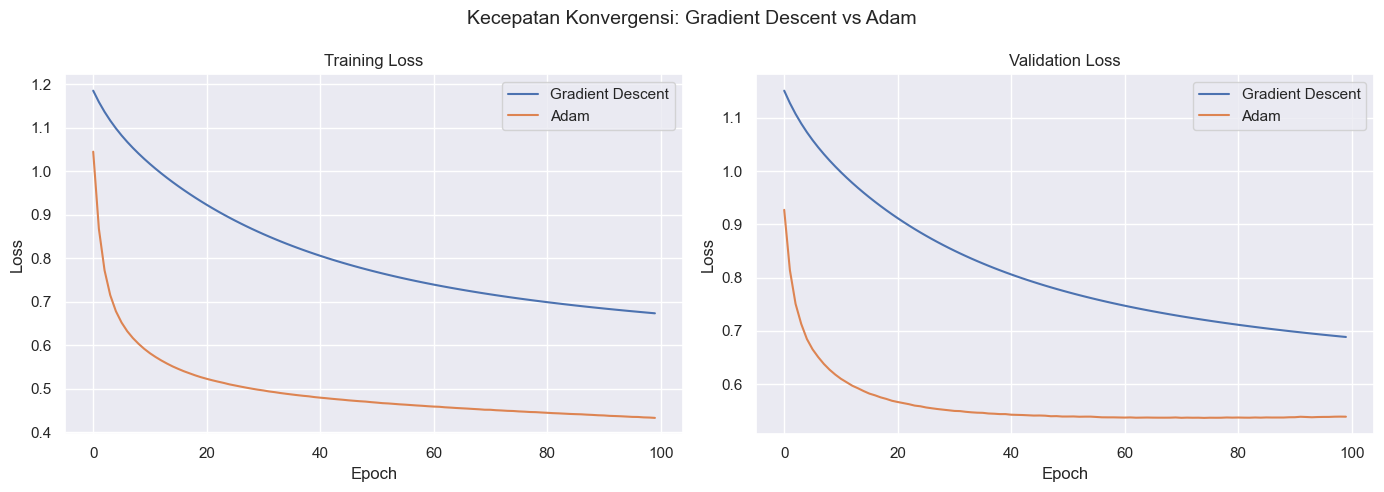

,Final Val Loss,Best Val Loss,Best Epoch,Epoch 90% Converged,Total Time (s),Time / Epoch (ms),Accuracy,F1 Score
Optimizer,,,,,,,,
Adam,0.53863,0.53638,75,18,7.727,77.273,0.7365,0.7924
Gradient Descent,0.68841,0.68841,100,67,4.961,49.608,0.6770,0.7399


Optimizer tercepat konvergen (berdasarkan Epoch 90% Converged): Adam
Epoch 90% converged adalah epoch pertama saat model sudah mencapai 90% perbaikan loss (perubahan dari loss awal ke loss terbaik)


In [42]:
import time



def epoch_to_converge(loss_curve, tolerance=0.1):
    # mereturn epoch pertama yang membuat penurunan loss ada dalam batas toleransi 
    # misal toleransi = 0.1 berarti mengembalikan epoch pertama yang loss nya sudah menurun sebanyak 90% dari jarak total inital loss ke best loss
    
    if loss_curve is None or len(loss_curve) == 0:
        return np.nan

    initial_loss = float(loss_curve[0])
    best_loss = float(np.min(loss_curve))

    if np.isclose(initial_loss, best_loss):
        return 1

    target_loss = best_loss + tolerance * (initial_loss - best_loss)
    for epoch_idx, loss in enumerate(loss_curve, start=1):
        if float(loss) <= target_loss:
            return epoch_idx
    return len(loss_curve)


SPEED_HP = {
    'hidden_units':  [64, 64],
    'activation':    'relu',
    'learning_rate': 0.0001,
    'epochs':        100,
    'batch_size':    64,
}

speed_configs = [
    (None,  'Gradient Descent'),
    ('adam', 'Adam'),
]

speed_models, speed_histories, speed_labels, speed_times = [], [], [], []

print(f'[{datetime.datetime.now()}] Convergence-speed experiments started.')
for opt, label in speed_configs:
    print(f'  Training {label}...')

    model = FFNN()
    init = initialize_uniform(-0.5, 0.5, seed=42)
    model.add(Dense(SPEED_HP['hidden_units'][0], activation=SPEED_HP['activation'], weight_initializer=init, input_dim=INPUT_DIM))
    model.add(Dense(SPEED_HP['hidden_units'][1], activation=SPEED_HP['activation'], weight_initializer=init))
    model.add(Dense(1, activation='sigmoid', weight_initializer=initialize_uniform(-0.5, 0.5, seed=42)))
    model.compile(loss='bce', optimizer=opt)

    start = time.perf_counter()
    history = model.fit(
        X_train, y_train, X_val=X_val, y_val=y_val,
        batch_size=SPEED_HP['batch_size'],
        learning_rate=SPEED_HP['learning_rate'],
        epoch=SPEED_HP['epochs'], verbose=0
    )
    elapsed = time.perf_counter() - start

    speed_models.append(model)
    speed_histories.append(history)
    speed_labels.append(label)
    speed_times.append(elapsed)

print(f'[{datetime.datetime.now()}] Convergence-speed experiments completed.')

plot_loss_curves(speed_histories, speed_labels, title='Kecepatan Konvergensi: Gradient Descent vs Adam')

rows = []
for model, history, label, elapsed in zip(speed_models, speed_histories, speed_labels, speed_times):
    val_loss = history['val_loss'] if history.get('val_loss') else history['train_loss']

    best_epoch = int(np.argmin(val_loss) + 1)
    conv_epoch = epoch_to_converge(val_loss, tolerance=0.1)

    acc, f1 = evaluate(model, X_val, y_val)

    rows.append({
        'Optimizer': label,
        'Final Val Loss': round(float(val_loss[-1]), 5),
        'Best Val Loss': round(float(np.min(val_loss)), 5),
        'Best Epoch': best_epoch,
        'Epoch 90% Converged': conv_epoch,
        'Total Time (s)': round(float(elapsed), 3),
        'Time / Epoch (ms)': round(float(elapsed / SPEED_HP['epochs'] * 1000), 3),
        'Accuracy': round(float(acc), 4),
        'F1 Score': round(float(f1), 4),
    })

speed_results = pd.DataFrame(rows).set_index('Optimizer').sort_values('Epoch 90% Converged')
display(speed_results)

best_by_speed = speed_results.index[0]
print(f'Optimizer tercepat konvergen (berdasarkan Epoch 90% Converged): {best_by_speed}')
print("Epoch 90% converged adalah epoch pertama saat model sudah mencapai 90% perbaikan loss (perubahan dari loss awal ke loss terbaik)")

In [45]:
# Save Model
ffnn_model.save("saved_model.pkl")

# Load model
loaded_model = FFNN.load("saved_model.pkl")

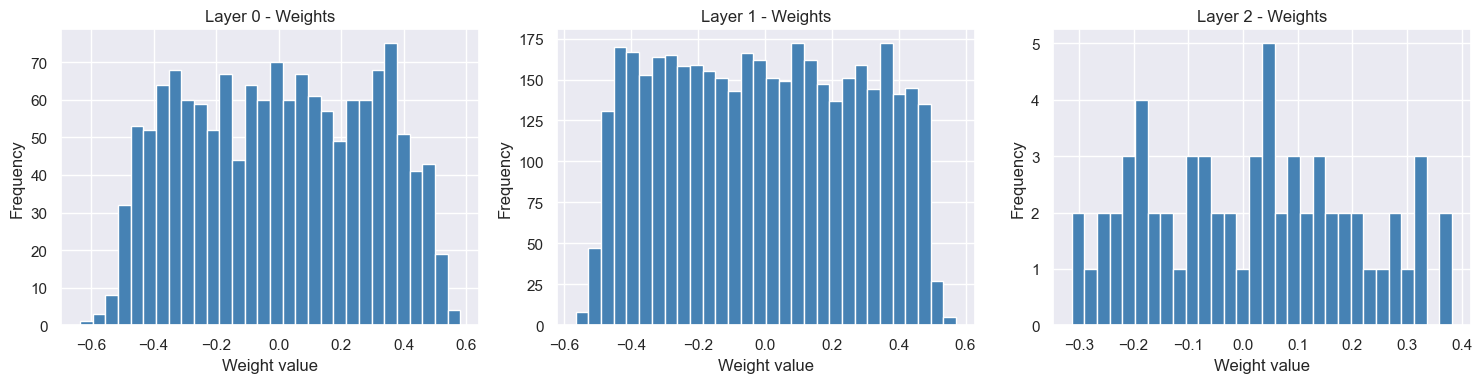

In [46]:
loaded_model.plot_weights()

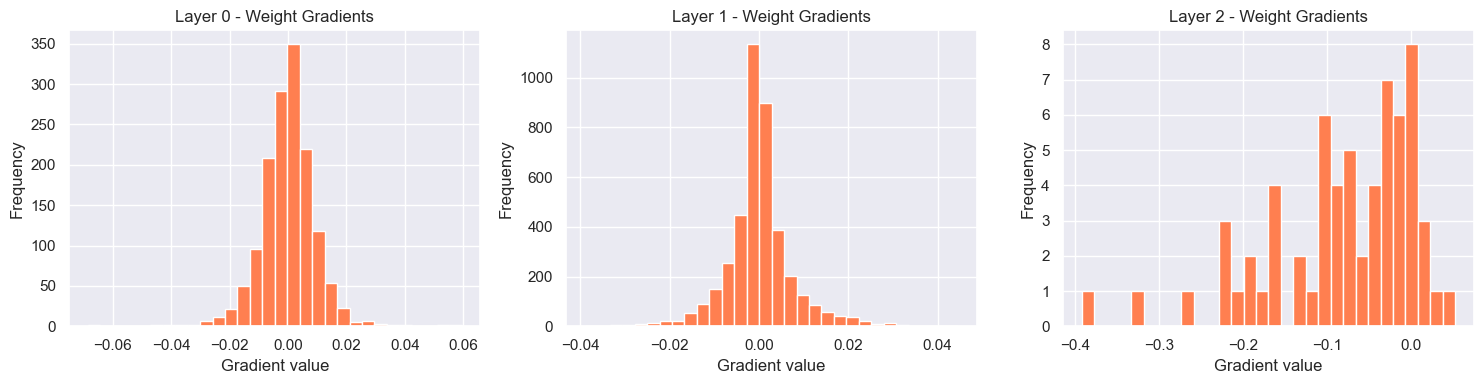

In [47]:
loaded_model.plot_gradients()